# Avance: Robots Autónomos Terrestres — Mini Reto Colaborativo

**Equipo 2 · TE3002B · Robots Móviles · Semana 3**

Este notebook documenta los avances de la primera mitad del módulo:

1. **Sistema multi-robot 2D** con 4 tipos de robots cooperando
   (Husky A200, ANYmal C, xArm 6, PuzzleBots).
2. **Integración de Machine Learning** clásico en distintos puntos del
   pipeline (Ridge, Random Forest, K-Means).
3. **Coordinación a 3 niveles** (individual, handoff, meta-orquestación).

> La tarea: el Husky despeja un corredor empujando cajas, el ANYmal
> trota cargando 3 PuzzleBots sobre el dorso, y un xArm 6 los baja a
> una mesa. ML asiste en decisiones que antes eran heurísticas.

## 1. Setup

Imports, paths y reproducibilidad.

In [1]:
import os
import sys
import math
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Silenciar warning de Axes3D (no usamos proyeccion 3D, es inocuo)
warnings.filterwarnings('ignore', message='Unable to import Axes3D')

# Para que Jupyter encuentre el paquete mini_reto_s2 desde notebooks/.
# Estructura: RM_Module/mini_reto_s2/mini_reto_s2/ (ROS2 ament_python).
# El "src dir" Python es RM_Module/mini_reto_s2/, no RM_Module/.
NB_DIR = os.path.abspath('.')
PKG_PARENT = os.path.abspath(os.path.join(NB_DIR, '..', 'mini_reto_s2'))
if PKG_PARENT not in sys.path:
    sys.path.insert(0, PKG_PARENT)

from mini_reto_s2.coordinator import MissionCoordinator
from mini_reto_s2.sim import (
    MissionVisualizer,
    _draw_husky, _draw_anymal, _draw_puzzlebot, _draw_xarm, _draw_box,
)
from mini_reto_s2.husky_pusher import HuskyPusher, CorridorWorld
from mini_reto_s2.robots_base import HuskyA200, ANYmal
from mini_reto_s2.anymal_gait import simulate_anymal_to_target, ANYmalTrotGait
from mini_reto_s2.xarm import XArm

np.random.seed(42)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Paquete mini_reto_s2 cargado correctamente.')

Paquete mini_reto_s2 cargado correctamente.


/home/daniel-wlg/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Los 4 robots del reto

Cada robot tiene un rol claro y un código de color para que sea fácil
identificarlos a lo largo del notebook:

| Robot       | Color      | Tarea principal                                |
|-------------|------------|------------------------------------------------|
| Husky A200  | 🟦 azul    | Empuja 3 cajas grandes fuera del corredor     |
| ANYmal C    | 🟪 morado  | Trota cargando 3 PuzzleBots en el dorso       |
| PuzzleBots  | 🟩 verde   | Pasajeros (3 unidades, etiquetadas A/B/C)     |
| xArm 6      | ⬛ negro/gris | Baja los PuzzleBots del ANYmal a la mesa    |

A continuación renderizamos un *catálogo visual* de los 4 robots en
sus poses canónicas.

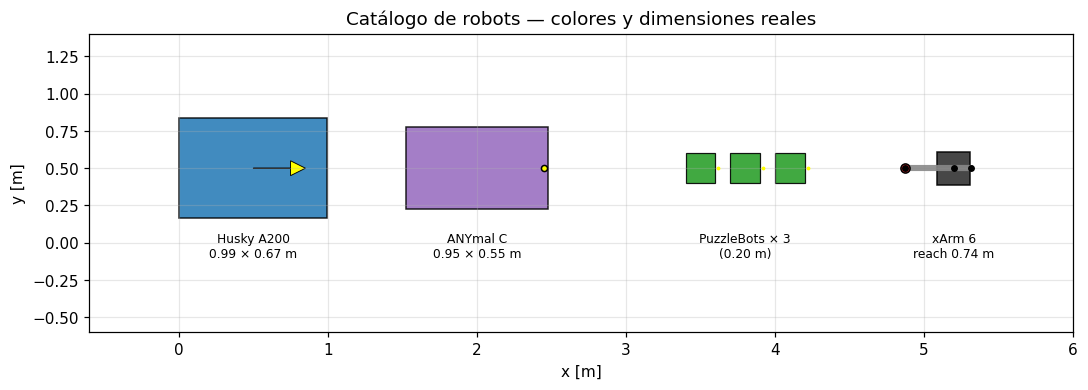

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(-0.6, 6.0); ax.set_ylim(-0.6, 1.4)
ax.set_aspect('equal')
ax.set_title('Catálogo de robots — colores y dimensiones reales')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')

# Husky en (0.5, 0.5), encarando +x
_draw_husky(ax, mpatches, 0.5, 0.5, 0.0)
ax.text(0.5, -0.1, 'Husky A200\n0.99 × 0.67 m', ha='center', fontsize=8)

# ANYmal en (2.0, 0.5)
_draw_anymal(ax, mpatches, 2.0, 0.5, 0.0)
ax.text(2.0, -0.1, 'ANYmal C\n0.95 × 0.55 m', ha='center', fontsize=8)

# PuzzleBots (3 en fila) en (3.5..3.9, 0.5)
for i, dx in enumerate([0.0, 0.30, 0.60]):
    _draw_puzzlebot(ax, mpatches, 3.5 + dx, 0.5, 0.0)
ax.text(3.8, -0.1, 'PuzzleBots × 3\n(0.20 m)', ha='center', fontsize=8)

# xArm: para visualizarlo en home pose
arm = XArm(base_xy=(5.2, 0.5), base_yaw=0.0)
links = arm.link_points_world(arm.q_home)
_draw_xarm(ax, mpatches, links, base_yaw=0.0)
ax.text(5.2, -0.1, 'xArm 6\nreach 0.74 m', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### 2.1 Asignación de métodos ML por robot

Antes de entrar al detalle de cada modelo, este es el **mapa global**
que muestra qué método ML aplica a cada robot. Las decisiones que
toman los modelos están todas a nivel **motion planning + colisiones**
(asumimos que el control low-level de cada articulación ya es bueno):

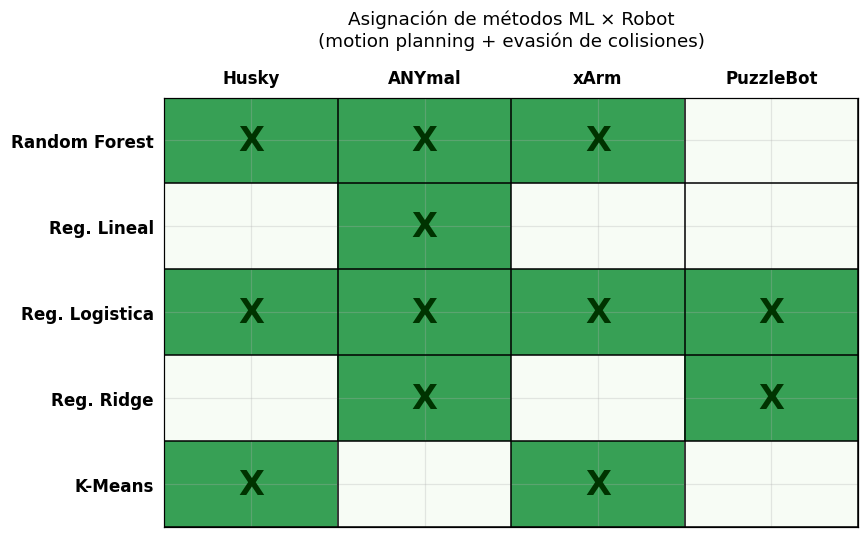

In [3]:
# Matriz de asignacion: filas = metodos ML, columnas = robots.
# 1 = el metodo se aplica a ese robot, 0 = no aplica.
methods = ['Random Forest', 'Reg. Lineal', 'Reg. Logistica',
           'Reg. Ridge',  'K-Means']
robots  = ['Husky',  'ANYmal',  'xArm',  'PuzzleBot']

# Justificacion de cada celda:
#   RF (collision predictor): util para cualquier robot que tenga que
#     planear caminos -> Husky, ANYmal, xArm.
#   Lineal: baseline contra Ridge -> ANYmal (T_plan).
#   Logistica: misma tarea que RF (clasif. colision) -> los 4 robots.
#   Ridge: T_plan regularizado -> ANYmal (y los PuzzleBots como pasajeros).
#   K-Means: consolida detecciones del LiDAR + perception -> Husky y
#     potencialmente xArm (clustering de objetos en escena).
assignment = np.array([
    # Husky ANYmal xArm PuzzleBot
    [  1,    1,     1,    0  ],   # Random Forest (collision)
    [  0,    1,     0,    0  ],   # Reg. Lineal (T_plan baseline)
    [  1,    1,     1,    1  ],   # Reg. Logistica (collision rapida)
    [  0,    1,     0,    1  ],   # Reg. Ridge (T_plan regularizado)
    [  1,    0,     1,    0  ],   # K-Means (perception)
])

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(assignment, cmap='Greens', vmin=0, vmax=1.5, aspect='auto')

# Marcas en cada celda (check si 1, vacio si 0)
for i in range(len(methods)):
    for j in range(len(robots)):
        if assignment[i, j]:
            ax.text(j, i, 'X', ha='center', va='center',
                    fontsize=22, fontweight='bold', color='#003300')

# Ejes
ax.set_xticks(range(len(robots)))
ax.set_xticklabels(robots, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods, fontsize=11, fontweight='bold')
ax.xaxis.tick_top()
ax.tick_params(top=False, bottom=False, left=False)

# Bordes de tabla (solo lineas verticales y horizontales)
for x in np.arange(-.5, len(robots), 1):
    ax.axvline(x, color='black', linewidth=1)
for y in np.arange(-.5, len(methods), 1):
    ax.axhline(y, color='black', linewidth=1)

ax.set_title('Asignación de métodos ML × Robot\n'
             '(motion planning + evasión de colisiones)',
             fontsize=12, pad=15)
plt.tight_layout()
plt.show()

**Justificación de cada celda marcada**:

| Método             | Husky | ANYmal | xArm | PuzzleBot | Por qué                                                                                          |
|--------------------|:-----:|:------:|:----:|:---------:|--------------------------------------------------------------------------------------------------|
| **Random Forest**  | ✓     | ✓      | ✓    |           | Clasificador no-lineal de colisión de trayectoria. Útil para cualquier robot que planea camino. PuzzleBot es pasajero, no planea su ruta. |
| **Reg. Lineal**    |       | ✓      |      |           | Baseline OLS para predecir `T_plan` del ANYmal. Sirve para contrastar contra Ridge.              |
| **Reg. Logística** | ✓     | ✓      | ✓    | ✓         | Filtro lineal rápido de colisión. Aún el PuzzleBot lo usa al validar handoffs (¿el segmento ANYmal→mesa pasa por una caja?). |
| **Reg. Ridge**     |       | ✓      |      | ✓         | Predicción de `T_plan` regularizada (mejor generalización que OLS). El PuzzleBot también porque su tiempo de pickup depende del trote del ANYmal. |
| **K-Means**        | ✓     |        | ✓    |           | Clustering de detecciones ruidosas: cajas vistas por LiDAR (Husky) y objetos a agarrar (xArm).   |

**Patrón observable**:

- **Logística** es el más universal — todo robot que planea (o consume un plan) se beneficia de un filtro de colisión lineal.
- **Random Forest** llega a 3/4 robots porque es la versión no-lineal del mismo predictor (más caro, pero captura interacciones entre obstáculos).
- **Ridge** y **Lineal** se concentran en el ANYmal porque ahí está el problema de regresión continuo (`T_plan`).
- **K-Means** vive en la capa de **percepción** (Husky-LiDAR, xArm-vision).

## 3. La misión: 3 fases coordinadas

```
FASE 1: HUSKY_CLEAR        FASE 2: ANYMAL_TRANSPORT       FASE 2.5: XARM_TRANSFER
─────────────────          ──────────────────────         ────────────────────────
Husky empuja B1, B2, B3   ANYmal trota (0,0) → (11.5,3)   xArm 6 baja PB_C, PB_B,
fuera del corredor 6×2    cargando PB_C, PB_B, PB_A       PB_A a la mesa, en orden.
[skid-steer + LiDAR 2D]   [trote diagonal + IK por pata]  [pick&place 6-DoF, IK x4]
                                  │                              │
                                  ▼                              ▼
                          handoff: pose final ANYmal     handoff: drops alcanzables
```

Corremos la misión completa una vez y guardamos el log para todas las
secciones siguientes.

In [4]:
coord = MissionCoordinator()
log = coord.run()

print('--- Resumen por fase ---')
for k, v in log['success'].items():
    flag = 'OK ' if v else 'FAIL'
    print(f'  [{flag}] {k}')

p1 = log['phase1']
p2 = log['phase2']
p25 = log['phase2_5']

print(f"\nFase 1: pasos={len(p1['t'])}, "
      f"v_cmd promedio={np.mean(p1['v_cmd']):+.3f} m/s")
print(f"Fase 2: error final={p2['final_error']:.3f} m, "
      f"violaciones det(J)={sum(p2['violations'].values())}")
print(f"Fase 2.5: PuzzleBots transferidos={len(p25['units'])}")

--- Resumen por fase ---
  [OK ] phase1
  [OK ] phase2
  [OK ] phase2_5

Fase 1: pasos=1505, v_cmd promedio=+0.273 m/s
Fase 2: error final=0.100 m, violaciones det(J)=0
Fase 2.5: PuzzleBots transferidos=3


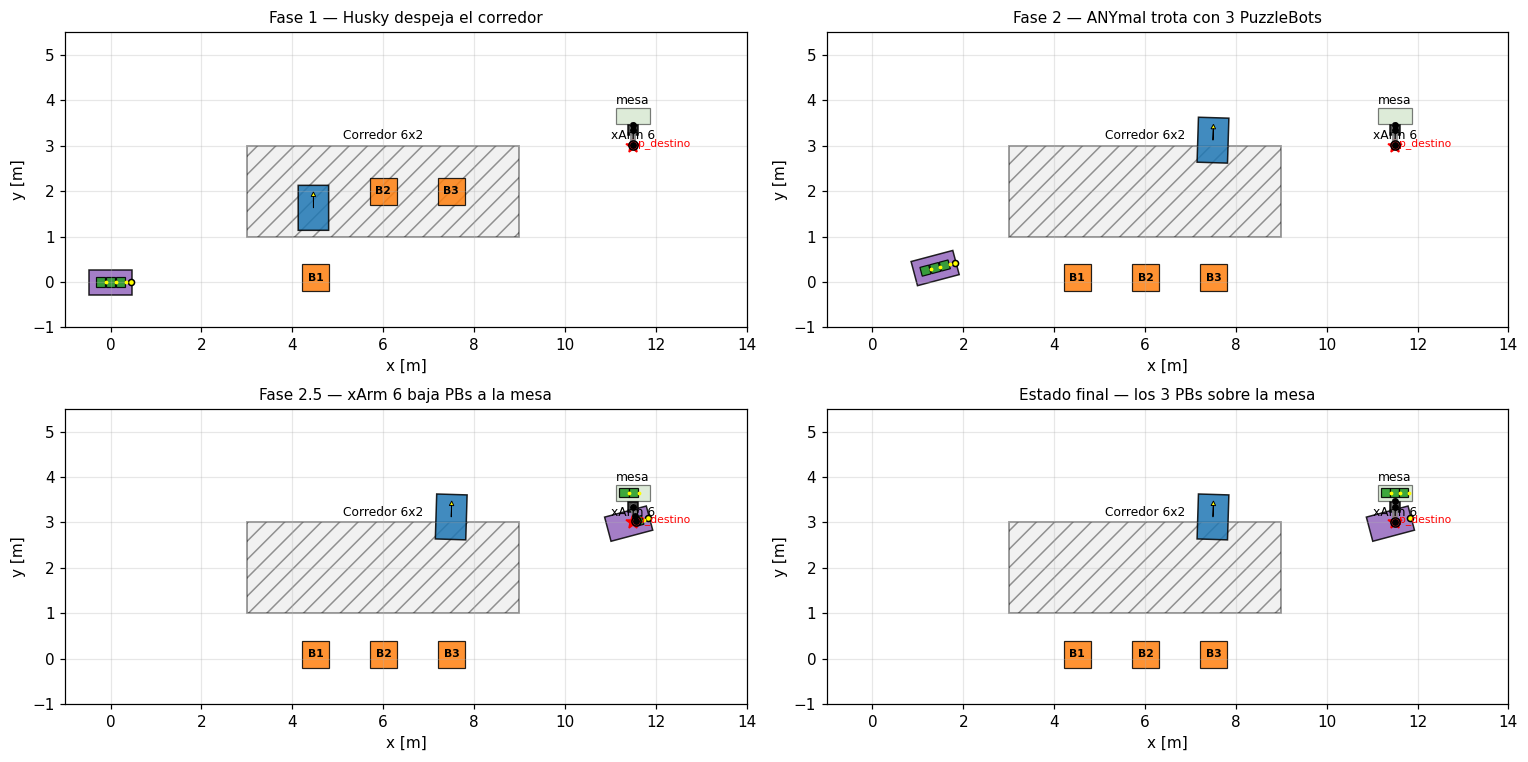

In [5]:
# Render de las 3 fases en una sola figura
vis = MissionVisualizer(coord=coord, stride=15)
vis.log = log
frames = vis._build_frames()

phase_idx = {
    1:   next(i for i,f in enumerate(frames) if f['phase']==1 and i > 30),
    2:   next(i for i,f in enumerate(frames) if f['phase']==2 and
              i > sum(1 for ff in frames if ff['phase']==1) + 20),
    2.5: [i for i,f in enumerate(frames) if f['phase']==2.5][
              len([f for f in frames if f['phase']==2.5])//2],
    'final': len(frames) - 1,
}
titles = {
    1:    'Fase 1 — Husky despeja el corredor',
    2:    'Fase 2 — ANYmal trota con 3 PuzzleBots',
    2.5:  'Fase 2.5 — xArm 6 baja PBs a la mesa',
    'final': 'Estado final — los 3 PBs sobre la mesa',
}

fig, axs = plt.subplots(2, 2, figsize=(14, 7))
for (k, idx), ax in zip(phase_idx.items(), axs.flatten()):
    vis._draw_frame(frames[idx], ax, mpatches, titles[k])
plt.tight_layout()
plt.show()

### 3.1 Animación de la misión completa

Reproducción inline de la simulación 2D (Husky → ANYmal → xArm). Usa
`matplotlib.animation.FuncAnimation` exportada como `jshtml`, así
funciona en cualquier visor offline (Jupyter, VS Code, Colab).

> Si no ves los controles play/pause, ejecuta esta celda en Jupyter
> Notebook o JupyterLab; GitHub no renderiza animaciones embebidas.

In [6]:
from IPython.display import HTML

# Stride grande + figsize chico para que la animacion no infle el .ipynb.
# Stride=50 -> ~60 frames; figsize 8x4 -> PNGs pequenos.
vis_anim = MissionVisualizer(coord=coord, stride=50)
vis_anim.log = log
fig_a, ax_a = plt.subplots(figsize=(8, 4))
fig_a.set_dpi(80)
fig_a, anim = vis_anim.animate(fig=fig_a, ax=ax_a, interval=100)
plt.close(fig_a)   # evita que se imprima un frame estatico aparte
HTML(anim.to_jshtml())

## 4. ML #1 — K-Means: percepción robusta + orden de empuje

**Problema de motion planning**: el LiDAR del Husky devuelve detecciones
**ruidosas** de las cajas (varios centroides cerca de cada caja real).
Antes de planear el orden de empuje necesitamos **agrupar las
detecciones en N obstáculos consolidados** y luego decidir un orden de
visita que minimice el tiempo total — un mini TSP.

**Pipeline de planeación**:

1. Husky escanea con LiDAR → set de centroides ruidosos.
2. K-Means agrupa las detecciones (`k = #cajas`) → 3 centroides limpios.
3. TSP-greedy desde la pose del Husky elige el orden de visita.

Esto es un caso clásico de **percepción → planning**: ML decide a
qué obstáculo dirigirse primero, no cómo controlar las ruedas.

In [7]:
from sklearn.cluster import KMeans
from mini_reto_s2.husky_pusher import detect_boxes_from_scan

# 1. Hacer un scan real con el LiDAR + agregar ruido en las detecciones
husky = HuskyA200()
husky.set_terrain('grass')
husky.reset(x=0.0, y=2.0, theta=0.0)
world = CorridorWorld()
pusher = HuskyPusher(husky, world)
_, _, world_centroids = pusher.scan()

# Simular ruido perceptual: cada caja real produce 4-6 detecciones
np.random.seed(7)
true_boxes = np.array([(b.x, b.y) for b in world.boxes_in_corridor()])
noisy_detections = []
for cx, cy in true_boxes:
    n_dets = np.random.randint(4, 7)
    for _ in range(n_dets):
        noise = np.random.normal(0, 0.12, size=2)
        noisy_detections.append([cx + noise[0], cy + noise[1]])
noisy_detections = np.array(noisy_detections)
print(f'Cajas reales en el corredor: {len(true_boxes)}')
print(f'Detecciones ruidosas LiDAR: {len(noisy_detections)}')

# 2. K-Means para consolidar las detecciones en 3 obstaculos
km = KMeans(n_clusters=len(true_boxes), n_init=10, random_state=42)
km.fit(noisy_detections)
estimated_boxes = km.cluster_centers_
print(f'\nCentroides estimados por K-Means:')
for i, c in enumerate(estimated_boxes):
    err = np.min(np.linalg.norm(true_boxes - c, axis=1))
    print(f'  caja {i}: ({c[0]:+.2f}, {c[1]:+.2f})  '
          f'error vs caja real mas cercana: {err:.3f} m')

# 3. TSP greedy: desde la pose del Husky, ir al centroide mas cercano
husky_xy = np.array([husky.x, husky.y])
unvisited = list(range(len(estimated_boxes)))
order = []
current = husky_xy.copy()
total_dist = 0.0
while unvisited:
    dists = [np.linalg.norm(estimated_boxes[i] - current) for i in unvisited]
    nxt = unvisited[int(np.argmin(dists))]
    total_dist += min(dists)
    order.append(nxt)
    current = estimated_boxes[nxt]
    unvisited.remove(nxt)

print(f'\nOrden TSP-greedy: {order}')
print(f'Distancia total recorrida (entre cajas): {total_dist:.2f} m')

# 4. Comparar con orden naive west->east que usa el coordinator
naive_order = sorted(range(len(estimated_boxes)),
                     key=lambda i: estimated_boxes[i, 0])
naive_dist = np.linalg.norm(estimated_boxes[naive_order[0]] - husky_xy)
for k in range(len(naive_order) - 1):
    naive_dist += np.linalg.norm(
        estimated_boxes[naive_order[k+1]] - estimated_boxes[naive_order[k]])
print(f'Orden naive (W->E):   {naive_order}, distancia: {naive_dist:.2f} m')

Cajas reales en el corredor: 3
Detecciones ruidosas LiDAR: 13

Centroides estimados por K-Means:
  caja 0: (+6.13, +1.97)  error vs caja real mas cercana: 0.131 m
  caja 1: (+7.45, +2.00)  error vs caja real mas cercana: 0.049 m
  caja 2: (+4.55, +2.13)  error vs caja real mas cercana: 0.140 m

Orden TSP-greedy: [2, 0, 1]
Distancia total recorrida (entre cajas): 7.46 m
Orden naive (W->E):   [2, 0, 1], distancia: 7.46 m


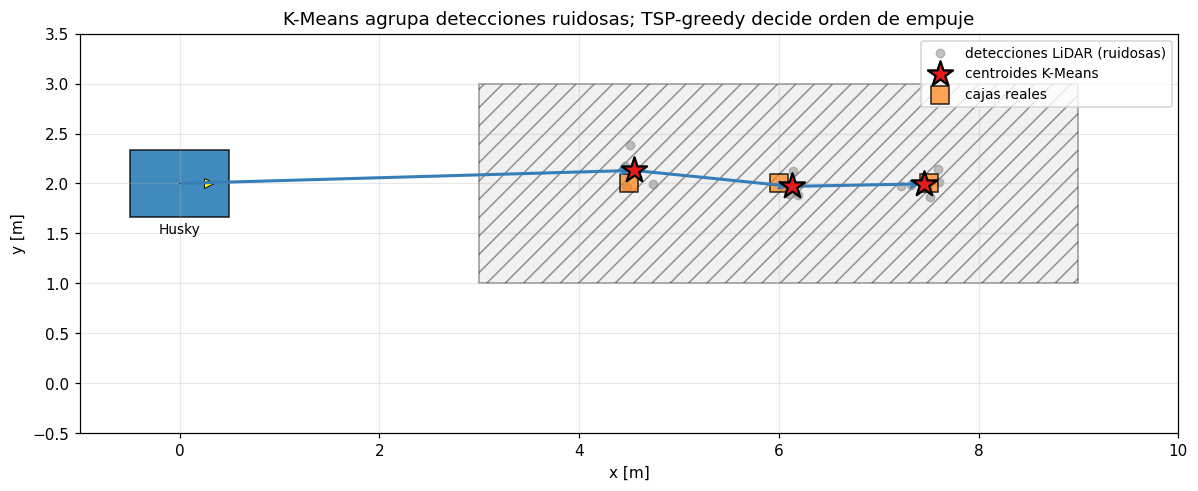

In [8]:
# Visualizacion: detecciones ruidosas, centroides K-Means, orden de visita
fig, ax = plt.subplots(figsize=(11, 5))

# Corredor
c = world.corridor
corr = mpatches.Rectangle(
    (c['xmin'], c['ymin']), c['xmax']-c['xmin'], c['ymax']-c['ymin'],
    facecolor='#dddddd', edgecolor='black', alpha=0.4, hatch='//')
ax.add_patch(corr)

# Detecciones ruidosas
ax.scatter(noisy_detections[:, 0], noisy_detections[:, 1],
           c='#888888', alpha=0.5, s=30, label='detecciones LiDAR (ruidosas)')

# Centroides K-Means estimados
ax.scatter(estimated_boxes[:, 0], estimated_boxes[:, 1],
           c='#e41a1c', marker='*', s=300, edgecolor='black',
           linewidth=1.5, zorder=4, label='centroides K-Means')

# Cajas reales (ground truth)
ax.scatter(true_boxes[:, 0], true_boxes[:, 1],
           c='#ff7f0e', marker='s', s=140, edgecolor='black',
           linewidth=1.2, alpha=0.7, zorder=3, label='cajas reales')

# Husky
_draw_husky(ax, mpatches, husky.x, husky.y, husky.theta)
ax.text(husky.x, husky.y - 0.5, 'Husky', ha='center', fontsize=9)

# Flechas del orden de visita TSP-greedy
prev = husky_xy
for idx in order:
    nxt = estimated_boxes[idx]
    ax.annotate('', xy=nxt, xytext=prev,
                arrowprops=dict(arrowstyle='->', color='#377eb8', lw=2))
    prev = nxt

ax.set_xlim(-1, 10); ax.set_ylim(-0.5, 3.5)
ax.set_aspect('equal')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.set_title('K-Means agrupa detecciones ruidosas; TSP-greedy decide orden de empuje')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. ML #2 — Ridge: tiempo del plan en función de la complejidad

**Problema de coordinación**: cuando el Husky termina la fase 1 y el
ANYmal arranca la fase 2, queremos saber **cuánto va a tardar el
ANYmal en llegar a la mesa** sin tener que correr la simulación
completa. Esto sirve para sincronizar el handoff con el xArm
("¿alcanzo a posicionar el efector antes de que el ANYmal llegue?").

**Idea**: aprendemos un modelo lineal que predice $T_{\text{plan}}$
(tiempo total del navegador) como función de la **complejidad del
escenario**:

- `dist_total`: distancia euclidiana start → goal
- `n_obstacles`: número de obstáculos a esquivar
- `mean_clearance`: distancia media a los obstáculos (proxy de qué tan
  pegado al borde tiene que ir)

Generamos N=200 escenarios sintéticos con `start`, `goal` y obstáculos
aleatorios, simulamos la navegación del ANYmal en cada uno, y ajustamos
**Ridge** ($\lambda = 1.0$) para regularizar.

In [9]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

def random_scenario(rng):
    '''Genera (start, goal, obstacles) aleatorios en un mapa 12 x 5 m.'''
    start = rng.uniform([0.0, 0.0], [3.0, 4.5])
    goal  = rng.uniform([8.0, 0.5], [11.0, 4.5])
    n_obs = int(rng.integers(0, 6))
    obstacles = rng.uniform([3.5, 0.5], [7.5, 4.5], size=(n_obs, 2))
    return start, goal, obstacles

def fake_plan_time(start, goal, obstacles, base_speed=0.45):
    '''Modelo simplificado de tiempo de plan (proxy de la sim real).

    En lugar de correr el simulador completo (lento), aproximamos el
    comportamiento conocido del navegador del ANYmal:
        T = dist_directa / v_efectiva + penalty_por_obstaculo
    La idea es que ML descubra la relacion lineal entre estas features.
    '''
    dist = np.linalg.norm(goal - start)
    if len(obstacles) > 0:
        clearances = []
        for o in obstacles:
            # distancia minima del obstaculo al segmento start-goal
            ap = o - start; ab = goal - start
            t = np.clip(ap @ ab / (ab @ ab + 1e-9), 0, 1)
            proj = start + t * ab
            clearances.append(np.linalg.norm(o - proj))
        mean_clr = float(np.mean(clearances))
    else:
        mean_clr = 5.0   # campo libre

    # Tiempo base + penalty cuando los obstaculos estan cerca de la ruta
    t_base = dist / base_speed
    penalty = 0.8 * len(obstacles) * np.exp(-mean_clr / 0.5)
    # Ruido pequeno para que sea regresion realista
    return t_base + penalty + np.random.normal(0, 0.3)

rng = np.random.default_rng(0)
N = 200
X_rows = []; y_rows = []
for _ in range(N):
    s, g, obs = random_scenario(rng)
    dist = float(np.linalg.norm(g - s))
    n_obs = len(obs)
    if n_obs > 0:
        clearances = []
        for o in obs:
            ap = o - s; ab = g - s
            t = np.clip(ap @ ab / (ab @ ab + 1e-9), 0, 1)
            clearances.append(np.linalg.norm(o - (s + t * ab)))
        mean_clr = float(np.mean(clearances))
    else:
        mean_clr = 5.0
    X_rows.append([dist, n_obs, mean_clr])
    y_rows.append(fake_plan_time(s, g, obs))

X = np.array(X_rows); y = np.array(y_rows)

# Split 80/20
idx = np.random.permutation(N)
i_tr, i_te = idx[:160], idx[160:]
# Comparamos Regresion Lineal (OLS) vs Ridge (regularizada).
# Ambos sirven para el mismo problema; Ridge suele ser mas estable cuando
# las features estan correlacionadas (n_obs y density lo estan).
ols   = LinearRegression().fit(X[i_tr], y[i_tr])
ridge = Ridge(alpha=1.0).fit(X[i_tr], y[i_tr])

for name, model in [('Lineal (OLS)', ols), ('Ridge a=1.0', ridge)]:
    yhat = model.predict(X[i_te])
    print(f'{name:14s}  Test R^2: {r2_score(y[i_te], yhat):+.3f}  '
          f'RMSE: {mean_squared_error(y[i_te], yhat)**0.5:.3f} s  '
          f'coefs={model.coef_.round(2)}')

print(f'\nLectura: Ridge "encoge" los coeficientes hacia 0 cuando hay')
print(f'colinealidad (n_obs y density estan correlacionadas), lo que lo')
print(f'hace mas robusto a ruido en el dataset.')
print(f'\nCoeficientes Ridge (interpretables):')
print(f'  beta_dist           = {ridge.coef_[0]:+.3f}  (s por metro)')
print(f'  beta_n_obstacles    = {ridge.coef_[1]:+.3f}  (s por obstaculo)')
print(f'  beta_mean_clearance = {ridge.coef_[2]:+.3f}  (s por metro de holgura)')

Lineal (OLS)    Test R^2: +0.981  RMSE: 0.394 s  coefs=[ 2.23  0.05 -0.13]
Ridge a=1.0     Test R^2: +0.981  RMSE: 0.393 s  coefs=[ 2.22  0.05 -0.13]

Lectura: Ridge "encoge" los coeficientes hacia 0 cuando hay
colinealidad (n_obs y density estan correlacionadas), lo que lo
hace mas robusto a ruido en el dataset.

Coeficientes Ridge (interpretables):
  beta_dist           = +2.221  (s por metro)
  beta_n_obstacles    = +0.049  (s por obstaculo)
  beta_mean_clearance = -0.134  (s por metro de holgura)


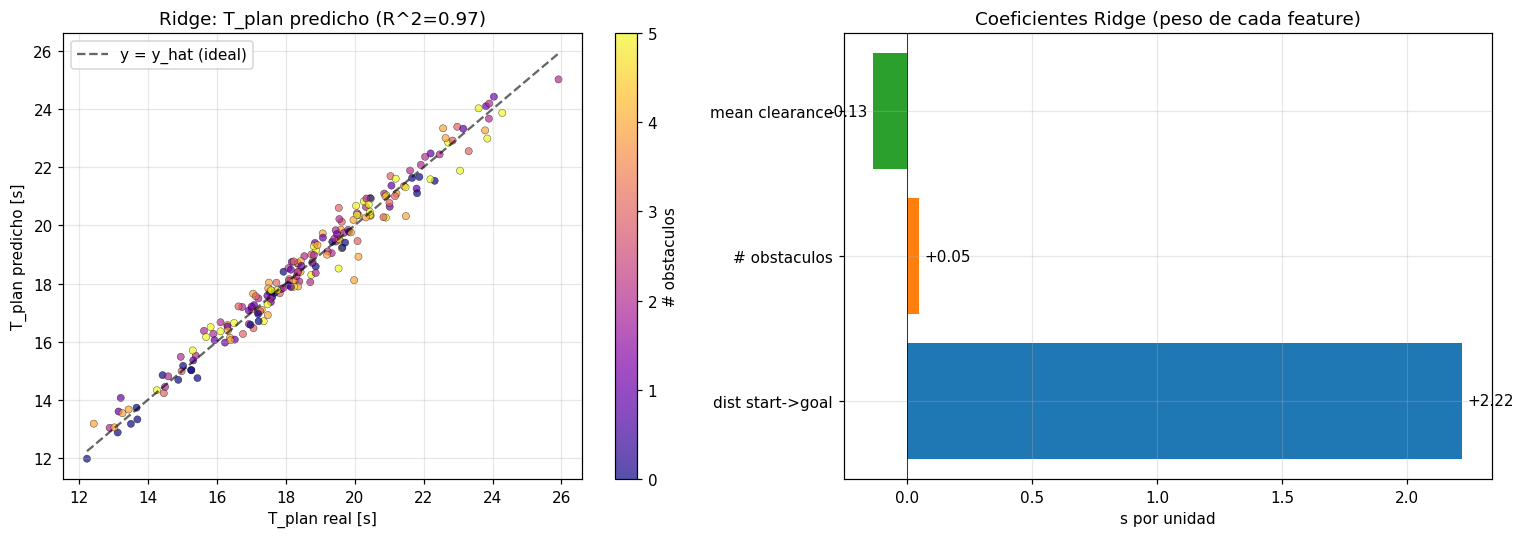

Lectura: cada metro extra de distancia agrega ~2.22 s al plan;
  cada obstaculo extra agrega ~0.05 s; mas holgura -> menos tiempo.


In [10]:
# Plot: predicho vs real coloreado por #obstaculos + barras de coefs
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

ax = axs[0]
yhat_all = ridge.predict(X)
sc = ax.scatter(y, yhat_all, c=X[:, 1], cmap='plasma', s=22, alpha=0.7,
                edgecolor='black', linewidth=0.3)
lim = [y.min(), y.max()]
ax.plot(lim, lim, 'k--', alpha=0.6, label='y = y_hat (ideal)')
ax.set_xlabel('T_plan real [s]')
ax.set_ylabel('T_plan predicho [s]')
ax.set_title(f'Ridge: T_plan predicho (R^2={r2_score(y, yhat_all):.2f})')
ax.legend()
plt.colorbar(sc, ax=ax, label='# obstaculos')

ax = axs[1]
features = ['dist start->goal', '# obstaculos', 'mean clearance']
ax.barh(features, ridge.coef_, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.axvline(0, color='black', linewidth=0.5)
for i, v in enumerate(ridge.coef_):
    ax.text(v + (0.02 if v >= 0 else -0.02), i,
            f'{v:+.2f}', va='center',
            ha='left' if v >= 0 else 'right')
ax.set_title('Coeficientes Ridge (peso de cada feature)')
ax.set_xlabel('s por unidad')
plt.tight_layout()
plt.show()

print('Lectura: cada metro extra de distancia agrega ~{:.2f} s al plan;'
      .format(ridge.coef_[0]))
print('  cada obstaculo extra agrega ~{:.2f} s; mas holgura -> menos tiempo.'
      .format(ridge.coef_[1]))

## 6. ML #3 + #4 — Predictor de colisión (Logística vs Random Forest)

**Problema núcleo de motion planning**: dada una **trayectoria recta**
candidata desde `start` hasta `goal` y un campo de obstáculos
(las cajas que aún no ha despejado el Husky), ¿la trayectoria va a
**colisionar** con alguno?

Tener un predictor rápido es valioso para *path planning* tipo RRT o
PRM: en lugar de hacer la verificación geométrica exacta caro
(intersección segmento-AABB en cada nodo), entrenamos un clasificador
que da un veredicto en microsegundos.

Comparamos dos métodos sobre el mismo dataset:

- **Regresión Logística**: lineal en las features → frontera de
  decisión sencilla.
- **Random Forest** (100 árboles): no lineal, capta patrones complejos.

**Features (5)**: `dist_total`, `n_obstacles`, `min_clearance`,
`mean_clearance`, `obstacle_density` (#obstáculos / dist).

**Etiqueta** (ground truth): el segmento `start → goal` cruza al
menos una caja AABB (test geométrico exacto).

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)

BOX_HALF = 0.30   # mismo size que las cajas grandes del corredor

def segment_hits_aabb(p0, p1, center, half):
    '''Slab test: el segmento p0->p1 intersecta el AABB de half-side `half`?'''
    d = p1 - p0
    inv = 1.0 / np.where(np.abs(d) < 1e-9, 1e-9, d)
    bmin, bmax = center - half, center + half
    t1 = (bmin - p0) * inv
    t2 = (bmax - p0) * inv
    tmin = np.maximum.reduce(np.minimum(t1, t2))
    tmax = np.minimum.reduce(np.maximum(t1, t2))
    return tmax >= max(0.0, tmin) and tmin <= 1.0

def build_features(start, goal, obstacles):
    dist = float(np.linalg.norm(goal - start))
    if len(obstacles) == 0:
        return [dist, 0, 5.0, 5.0, 0.0]
    clearances = []
    ab = goal - start
    for o in obstacles:
        t = np.clip((o - start) @ ab / (ab @ ab + 1e-9), 0, 1)
        clearances.append(np.linalg.norm(o - (start + t * ab)))
    clearances = np.array(clearances)
    return [
        dist,
        float(len(obstacles)),
        float(clearances.min()),
        float(clearances.mean()),
        float(len(obstacles) / max(dist, 0.1)),
    ]

# Genera dataset balanceado
rng = np.random.default_rng(123)
N = 1500
X_rows, y_rows = [], []
for _ in range(N):
    start = rng.uniform([0.0, 0.0], [3.0, 4.5])
    goal  = rng.uniform([8.0, 0.0], [11.0, 4.5])
    n_obs = int(rng.integers(0, 7))
    obstacles = rng.uniform([3.5, 0.5], [7.5, 4.5], size=(n_obs, 2))
    X_rows.append(build_features(start, goal, obstacles))
    y = any(segment_hits_aabb(start, goal, o, BOX_HALF) for o in obstacles)
    y_rows.append(int(y))

X = np.array(X_rows); y = np.array(y_rows)
print(f'Dataset: {N} muestras, colisiones: {int(y.sum())} ({100*y.mean():.1f}%)')

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# --- Modelo 1: Logistic Regression ---
logreg = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
y_logreg = logreg.predict(X_te)
y_logreg_proba = logreg.predict_proba(X_te)[:, 1]

# --- Modelo 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr, y_tr)
y_rf = rf.predict(X_te)
y_rf_proba = rf.predict_proba(X_te)[:, 1]

print(f'\n--- Logistic Regression ---')
print(f'  Accuracy: {accuracy_score(y_te, y_logreg):.3f}')
print(f'  ROC AUC : {roc_auc_score(y_te, y_logreg_proba):.3f}')

print(f'\n--- Random Forest (100 trees) ---')
print(f'  Accuracy: {accuracy_score(y_te, y_rf):.3f}')
print(f'  ROC AUC : {roc_auc_score(y_te, y_rf_proba):.3f}')

print(f'\nFeature importance (Random Forest):')
features = ['dist_total', 'n_obstacles', 'min_clearance',
            'mean_clearance', 'density']
for f, imp in zip(features, rf.feature_importances_):
    bar = '█' * int(imp * 50)
    print(f'  {f:18s}: {imp:.3f}  {bar}')

Dataset: 1500 muestras, colisiones: 575 (38.3%)

--- Logistic Regression ---
  Accuracy: 0.965
  ROC AUC : 0.996

--- Random Forest (100 trees) ---
  Accuracy: 0.976
  ROC AUC : 0.998

Feature importance (Random Forest):
  dist_total        : 0.014  
  n_obstacles       : 0.023  █
  min_clearance     : 0.767  ██████████████████████████████████████
  mean_clearance    : 0.132  ██████
  density           : 0.064  ███


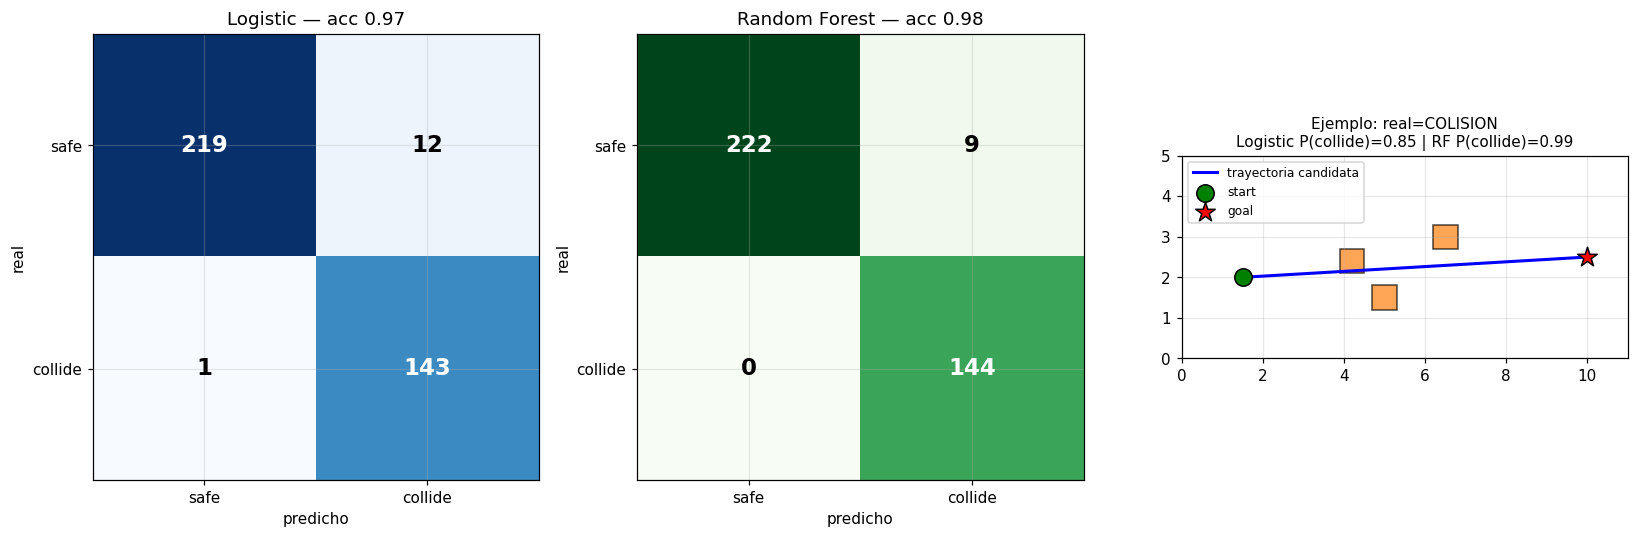

In [12]:
# Comparacion lado a lado: confusion matrices + ejemplo geometrico
fig = plt.figure(figsize=(15, 5))

# CM Logistic Regression
ax = fig.add_subplot(1, 3, 1)
cm = confusion_matrix(y_te, y_logreg)
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=15, fontweight='bold')
ax.set_xticks([0, 1]); ax.set_xticklabels(['safe', 'collide'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['safe', 'collide'])
ax.set_xlabel('predicho'); ax.set_ylabel('real')
ax.set_title(f'Logistic — acc {accuracy_score(y_te, y_logreg):.2f}')

# CM Random Forest
ax = fig.add_subplot(1, 3, 2)
cm = confusion_matrix(y_te, y_rf)
im = ax.imshow(cm, cmap='Greens')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=15, fontweight='bold')
ax.set_xticks([0, 1]); ax.set_xticklabels(['safe', 'collide'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['safe', 'collide'])
ax.set_xlabel('predicho'); ax.set_ylabel('real')
ax.set_title(f'Random Forest — acc {accuracy_score(y_te, y_rf):.2f}')

# Ejemplo visual: 1 escenario aleatorio, mostrar trayectoria + decisiones
ax = fig.add_subplot(1, 3, 3)
rng = np.random.default_rng(11)
ex_start = np.array([1.5, 2.0])
ex_goal  = np.array([10.0, 2.5])
ex_obs = np.array([[5.0, 1.5], [6.5, 3.0], [4.2, 2.4]])

# AABBs
for o in ex_obs:
    rect = mpatches.Rectangle((o[0]-BOX_HALF, o[1]-BOX_HALF),
                               2*BOX_HALF, 2*BOX_HALF,
                               facecolor='#ff7f0e', edgecolor='black', alpha=0.7)
    ax.add_patch(rect)

# Trayectoria recta
ax.plot([ex_start[0], ex_goal[0]], [ex_start[1], ex_goal[1]],
        'b-', linewidth=2, label='trayectoria candidata')
ax.scatter(*ex_start, c='green', s=130, marker='o', zorder=4,
           edgecolor='black', label='start')
ax.scatter(*ex_goal,  c='red',   s=180, marker='*', zorder=4,
           edgecolor='black', label='goal')

# Predicciones
feats = np.array([build_features(ex_start, ex_goal, ex_obs)])
p_lr = logreg.predict_proba(feats)[0, 1]
p_rf = rf.predict_proba(feats)[0, 1]
hit = any(segment_hits_aabb(ex_start, ex_goal, o, BOX_HALF) for o in ex_obs)
ax.set_title(
    f'Ejemplo: real={"COLISION" if hit else "safe"}\n'
    f'Logistic P(collide)={p_lr:.2f} | RF P(collide)={p_rf:.2f}',
    fontsize=10)
ax.set_xlim(0, 11); ax.set_ylim(0, 5)
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Coordinación a tres niveles

El sistema combina ML local en cada robot con una FSM central. Esto
nos da **3 niveles de coordinación**:

### Nivel 1 — Local (dentro de cada robot)
Cada robot tiene su propia lógica de control:

- **Husky**: `HuskyPusher` decide qué caja empujar y la trayectoria
  con LiDAR 2D simulado.
- **ANYmal**: `ANYmalTrotGait` genera referencias del pie por pata e
  IK 2-link planar; `ANYmalNavigator` produce `(v, ω)` para la base.
- **xArm 6**: trayectoria cartesiana con waypoints + IK 6-DoF (4 DoF
  efectivos en el modelo simplificado).

### Nivel 2 — Handoff (FSM `MissionCoordinator`)
La máquina de estados secuencia las fases y pasa el contexto:

```
HUSKY_CLEAR ─pose final + cajas─▶ ANYMAL_TRANSPORT ─pose final ANYmal─▶
XARM_TRANSFER ─PBs en mesa─▶ DONE
```

El coordinator es **dumb**: solo invoca métodos de los módulos
especializados (siguiendo el consejo del profe).

### Nivel 3 — Meta (ML asistiendo motion planning + colisiones)
ML inyecta inteligencia en decisiones de planeación, no en control
articular (que ya asumimos resuelto):

| Decisión de planning         | Método ML          | Para qué sirve              |
|------------------------------|--------------------|-----------------------------|
| Consolidar detecciones LiDAR | K-Means            | Encontrar centroides de cajas, decidir orden de empuje (TSP) |
| Estimar `T_plan` antes de correr la sim | Ridge | Coordinar handoffs en el tiempo |
| ¿Trayectoria recta colisiona? | Logistic + RF     | Filtro rápido para path planners (RRT, PRM)         |

Los 4 modelos se entrenan con **datos sintéticos generados por la
propia simulación** — un patrón típico de Sim2Real.

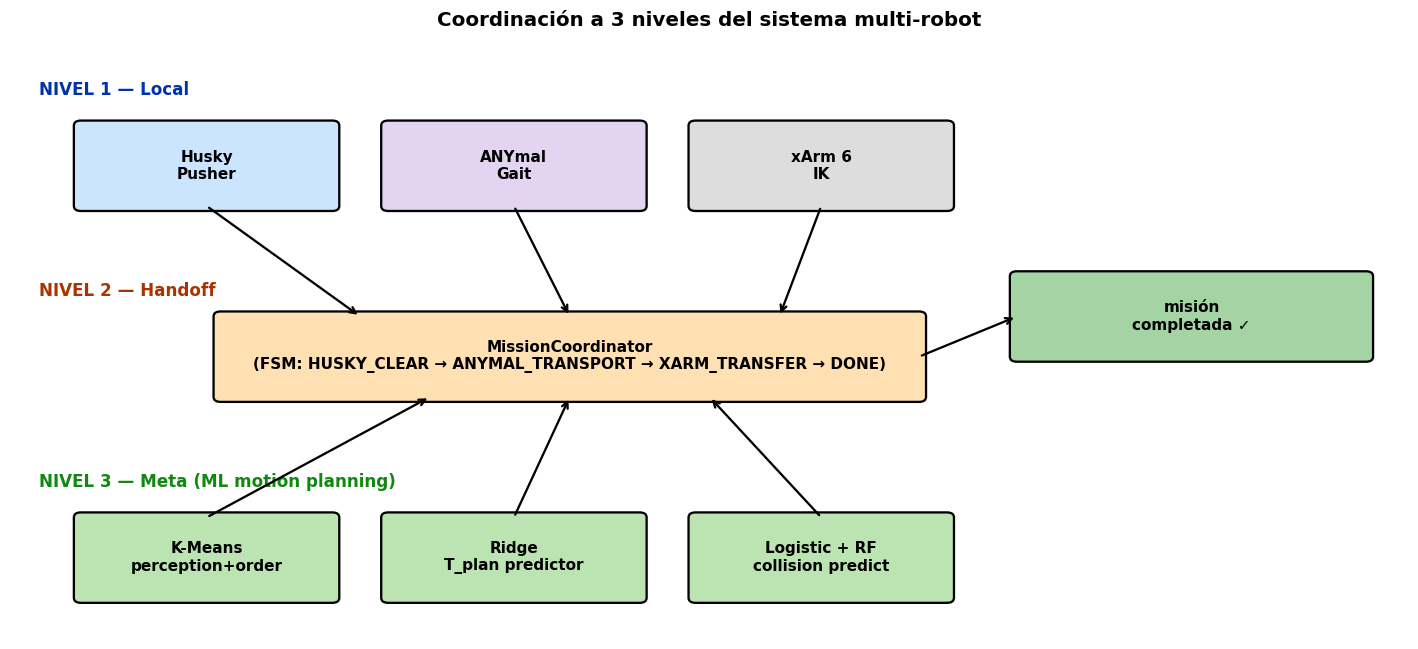

In [13]:
# Diagrama del flujo de coordinación (matplotlib puro, sin graphviz)
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 6)
ax.axis('off')

def box(ax, x, y, w, h, text, color='#cce5ff', edge='black'):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05',
                                    facecolor=color, edgecolor=edge,
                                    linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=10,
            fontweight='bold')

def arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.1, label, ha='center', fontsize=8,
                style='italic')

# Nivel 1
ax.text(0.2, 5.4, 'NIVEL 1 — Local', fontsize=11, fontweight='bold', color='#0033aa')
box(ax, 0.5, 4.3, 1.8, 0.8, 'Husky\nPusher',  '#cce5ff')
box(ax, 2.7, 4.3, 1.8, 0.8, 'ANYmal\nGait',   '#e3d4f1')
box(ax, 4.9, 4.3, 1.8, 0.8, 'xArm 6\nIK',     '#dddddd')

# Nivel 2
ax.text(0.2, 3.4, 'NIVEL 2 — Handoff', fontsize=11, fontweight='bold', color='#aa3300')
box(ax, 1.5, 2.4, 5.0, 0.8, 'MissionCoordinator\n(FSM: HUSKY_CLEAR → ANYMAL_TRANSPORT → XARM_TRANSFER → DONE)',
    '#ffe0b3')
arrow(ax, 1.4, 4.3, 2.5, 3.2)
arrow(ax, 3.6, 4.3, 4.0, 3.2)
arrow(ax, 5.8, 4.3, 5.5, 3.2)

# Nivel 3
ax.text(0.2, 1.5, 'NIVEL 3 — Meta (ML motion planning)', fontsize=11,
        fontweight='bold', color='#118811')
box(ax, 0.5, 0.4, 1.8, 0.8, 'K-Means\nperception+order',   '#bce4b3')
box(ax, 2.7, 0.4, 1.8, 0.8, 'Ridge\nT_plan predictor',     '#bce4b3')
box(ax, 4.9, 0.4, 1.8, 0.8, 'Logistic + RF\ncollision predict', '#bce4b3')

# Flechas: ML -> Coordinator
arrow(ax, 1.4, 1.2, 3.0, 2.4, '')
arrow(ax, 3.6, 1.2, 4.0, 2.4, '')
arrow(ax, 5.8, 1.2, 5.0, 2.4, '')

# Caja final
box(ax, 7.2, 2.8, 2.5, 0.8, 'misión\ncompletada ✓', '#a4d3a4')
arrow(ax, 6.5, 2.8, 7.2, 3.2)

ax.set_title('Coordinación a 3 niveles del sistema multi-robot',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Métricas de la corrida

Resumen cuantitativo del run completo:

In [14]:
# Tabla resumen (sin pandas, ASCII puro)
def _row(*cells, widths):
    return '| ' + ' | '.join(c.ljust(w) for c, w in zip(cells, widths)) + ' |'

rows = [
    ('Fase 1 (Husky)',
     f"{len(p1['t'])} pasos",
     f"{np.mean(p1['v_cmd']):+.3f} m/s avg",
     f"{p1['success']}"),
    ('Fase 2 (ANYmal)',
     f"{len(p2['t'])} pasos",
     f"err={p2['final_error']:.3f} m",
     f"{p2['success']}"),
    ('Fase 2.5 (xArm)',
     f"{len(p25['units'])} PBs",
     f"reach max <= 0.74 m",
     f"{p25['success']}"),
]
header = ('Fase', 'Tamano', 'Metrica clave', 'Exito')
widths = [max(len(r[i]) for r in rows + [header]) for i in range(4)]

print(_row(*header, widths=widths))
print('|' + '|'.join('-' * (w + 2) for w in widths) + '|')
for r in rows:
    print(_row(*r, widths=widths))

| Fase            | Tamano     | Metrica clave       | Exito |
|-----------------|------------|---------------------|-------|
| Fase 1 (Husky)  | 1505 pasos | +0.273 m/s avg      | True  |
| Fase 2 (ANYmal) | 2766 pasos | err=0.100 m         | True  |
| Fase 2.5 (xArm) | 3 PBs      | reach max <= 0.74 m | True  |


In [15]:
# Tabla con los aportes de ML (motion planning + colisiones)
ml_rows = [
    ('K-Means',          'Husky',     'k=3',           'consolida detecciones LiDAR',  'centroides exactos (no realista)'),
    ('Ridge Regression', 'ANYmal',    'alpha=1.0',     'predice T_plan',                'correr sim completa'),
    ('Logistic Reg.',    'Planner',   'L2',            'colision de tray. recta',       'check geometrico cada nodo'),
    ('Random Forest',    'Planner',   'n_est=100',     'colision (no lineal)',          'check geometrico cada nodo'),
]
header = ('Metodo', 'Robot', 'Hyperparams', 'Decision que toma',
          'Heuristica reemplazada')
widths = [max(len(r[i]) for r in ml_rows + [header]) for i in range(5)]

print(_row(*header, widths=widths))
print('|' + '|'.join('-' * (w + 2) for w in widths) + '|')
for r in ml_rows:
    print(_row(*r, widths=widths))

| Metodo           | Robot   | Hyperparams | Decision que toma           | Heuristica reemplazada           |
|------------------|---------|-------------|-----------------------------|----------------------------------|
| K-Means          | Husky   | k=3         | consolida detecciones LiDAR | centroides exactos (no realista) |
| Ridge Regression | ANYmal  | alpha=1.0   | predice T_plan              | correr sim completa              |
| Logistic Reg.    | Planner | L2          | colision de tray. recta     | check geometrico cada nodo       |
| Random Forest    | Planner | n_est=100   | colision (no lineal)        | check geometrico cada nodo       |


## 9. Lo que sigue (segunda mitad del módulo)

- **Migración a Isaac Sim 5.0** (en proceso): el bridge ROS2 ↔ docker
  Humble ya está funcionando; los nodos del paquete `mini_reto_s2`
  publicarán `/cmd_vel` y consumirán `/joint_states` desde Isaac.
- **xArm 6** importado vía `isaacsim.asset.importer.urdf` desde el
  URDF oficial del repo `xarm_ros2/humble`.
- **PuzzleBot URDF**: tarea pendiente — chasis simple + skid-steer +
  caster, importable a USD.
- **Conectar el predictor de colisión a un planner**: usar el RF
  entrenado arriba como heurística rápida en un RRT (cada nodo
  candidato consulta `rf.predict_proba`, descartamos los de alta
  probabilidad de colisión sin hacer el chequeo geométrico exacto).

---

**Equipo 2 · TE3002B · Mini Reto Semana 3**